<a href="https://colab.research.google.com/github/valentinroldan521-cpu/Modelizado-IA/blob/main/Copia_de_Pracitica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

# APLICAMOS LOS CONCEPTOS DE CRONOGRAMA Y FITNESS
def fitness_func(ga_instance, solution, solution_idx):

    # EL CRONOSOMA EQUIVALE A LOS DIAS DE INICIO
    tiempos_inicio = np.round(solution).astype(int)

    max_dia = 0
    uso_recursos = {} # Diccionario para trackear operarios por día {dia: total_op}
    penalizacion = 0

    for i in range(NUM_TAREAS):
        duracion, operarios = TASAS_OBRA[i]
        inicio = tiempos_inicio[i]
        fin = inicio + duracion

        if fin > max_dia:
            max_dia = fin

        # SE VERIFICA LA CANTIDAD DE OPERARIOS POR DIA
        for t in range(inicio, fin):
            uso_recursos[t] = uso_recursos.get(t, 0) + operarios

            # HABRA PENALIZACION SI SE SUPERA EL LIMITE
            if uso_recursos[t] > MAX_OPERARIOS:
                penalizacion += 100

    # CALCULO Del Fitness: 1 / DíasTotales (INCLUYE PENALIZACIÓN)
    # Si hay penalizacion, el fitness se suspende
    fitness = 1.0 / (max_dia + penalizacion)
    return fitness

# 4. CONFIGURAMOS EL PYGAD
ga_instance = pygad.GA(
    num_generations=200,
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=50,
    num_genes=NUM_TAREAS,

    # LOS DIAS DE INICIO PUEDEN TENER UN VALOR DESDE 0 HASTA EL 50 COMO MAXIMO (SE CUMPLEN HASTA 10 TAREAS COMO MAXIMO)
    init_range_low=0,
    init_range_high=40,
    gene_type=int,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=15,
    keep_elitism=2  # SE RECOMIENDA QUE EL MEJOR CRONOGRAMA NO SE PIERDA.
)



------------------------------
Mejor Cronograma Encontrado:
Tarea 0: Inicia día 5, Termina día 10
Tarea 1: Inicia día 3, Termina día 10
Tarea 2: Inicia día 11, Termina día 15
Tarea 3: Inicia día -9, Termina día -3
Tarea 4: Inicia día -10, Termina día -5
Tarea 5: Inicia día 13, Termina día 17
Tarea 6: Inicia día 11, Termina día 14
Tarea 7: Inicia día 15, Termina día 17
Tarea 8: Inicia día -7, Termina día -3
Tarea 9: Inicia día 15, Termina día 17

Tiempo Total de Obra (Makespan): 17 días
Fitness alcanzado: 0.058823529411764705


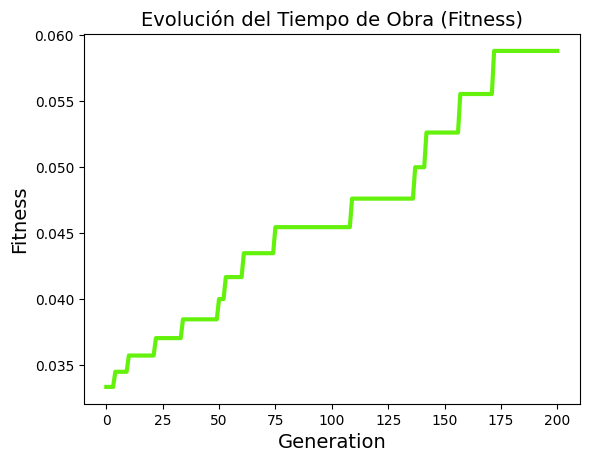

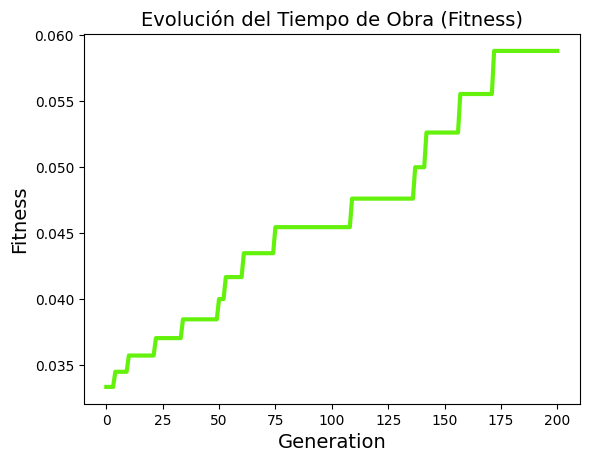

In [ ]:
# 5. EJECUTAMOS EL PYGAD
ga_instance.run()

# 6. ANALISIS DE RESULTADOS
solution, solution_fitness, solution_idx = ga_instance.best_solution()

print("-" * 30)
print(f"Mejor Cronograma Encontrado:")
tiempos_finales = np.round(solution).astype(int)
for i, inicio in enumerate(tiempos_finales):
    print(f"Tarea {i}: Inicia día {inicio}, Termina día {inicio + TASAS_OBRA[i][0]}")

makespan_final = max([tiempos_finales[i] + TASAS_OBRA[i][0] for i in range(NUM_TAREAS)])
print(f"\nTiempo Total de Obra (Makespan): {makespan_final} días")
print(f"Fitness alcanzado: {solution_fitness}")

# VISUALIZACION DE LA CURVA.
ga_instance.plot_fitness(title="Evolución del Tiempo de Obra (Fitness)")

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt